# Compare paired (M, nz)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_default_dtype(torch.float64)

Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=401  delta=0.062656  320*delta=20.0500 > tf=20.0: True
n_out=319  (excluding t=0)
t[0]=0.0000  t[-1]=19.9873  n_t=320
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=16.0, nz=640, tf=20.0, M=320, n_true=401, delta=0.062656, device='cuda')
Keys: ['U', 'U_raw', 'W', 'dataset', 'interp', 'interp_lin', 'interp_pw', 'kratio', 'stau', 't', 'z', 'z_dis']


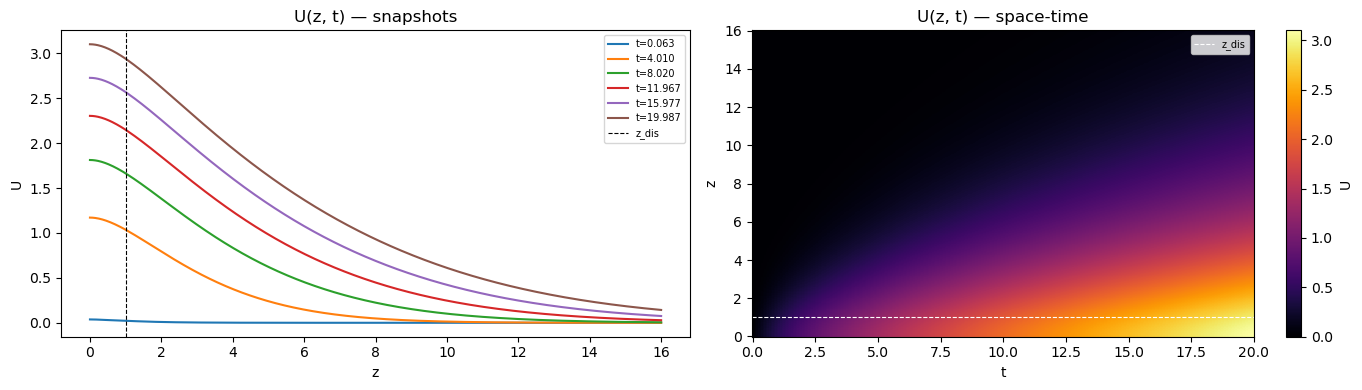

In [5]:
%run func_defs.ipynb
%run focus1_v4.ipynb

In [6]:
k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
tf      = 20.0
device  = 'cuda' if torch.cuda.is_available() else 'cpu'

# paired: each M gets a matching nz
M_list  = [320, 160]
nz_list = [640, 320]
pairs   = list(zip(M_list, nz_list))
print('Pairs (M, nz):', pairs)

Pairs (M, nz): [(320, 640), (160, 320)]


## Run solver for each pair

In [7]:
solvers = {}   # (M, nz) -> Solver

for M, nz in pairs:
    print(f'\n=== M={M}  nz={nz} ===')
    solvers[(M, nz)] = Solver(
        k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
        Lz=Lz, nz=nz, tf=tf,
        device=device, M=M, verbose=True,
    )


=== M=320  nz=640 ===
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=401  delta=0.062656  320*delta=20.0500 > tf=20.0: True
n_out=319  (excluding t=0)
t[0]=0.0000  t[-1]=19.9873  n_t=320

=== M=160  nz=320 ===
Interface alignment error: 0.00e+00
dt_stab=6.2500e-04  n_fine=32000  dt=6.2500e-04
n_true=201  delta=0.125625  160*delta=20.1000 > tf=20.0: True
n_out=159  (excluding t=0)
t[0]=0.0000  t[-1]=19.9744  n_t=160


## Summary table

In [8]:
print(f'  {"M":>6}  {"nz":>6}  {"n_true":>8}  {"delta":>10}  {"n_out":>6}  {"t[-1]":>8}')
print('-' * 58)
for (M, nz), sol in solvers.items():
    t = sol['t']
    print(f'  {M:>6d}  {nz:>6d}  {sol._n_true:>8d}  {sol._delta:>10.5f}'
          f'  {len(t)-1:>6d}  {t[-1].item():>8.4f}')

       M      nz    n_true       delta   n_out     t[-1]
----------------------------------------------------------
     320     640       401     0.06266     319   19.9873
     160     320       201     0.12563     159   19.9744


## Plot U(z,t) — one panel per pair

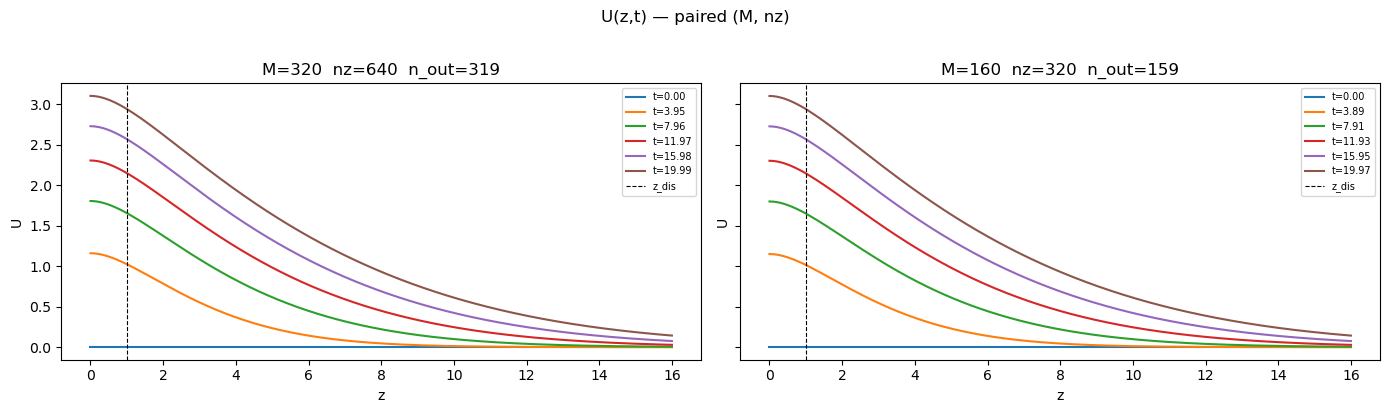

In [9]:
n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 4), sharey=True)

for ax, (M, nz) in zip(axes, pairs):
    sol   = solvers[(M, nz)]
    U     = sol['U'].cpu()
    z_cpu = sol['z'].cpu()
    t_cpu = sol['t'].cpu()
    idx   = torch.linspace(0, len(t_cpu) - 1, 6).long()
    for i in idx:
        ax.plot(z_cpu, U[:, i], label=f't={t_cpu[i]:.2f}')
    ax.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('U')
    ax.set_title(f'M={M}  nz={nz}  n_out={len(t_cpu)-1}')
    ax.legend(fontsize=7)

plt.suptitle('U(z,t) — paired (M, nz)', y=1.02)
plt.tight_layout(); plt.show()

## Error vs reference (M=320, nz=640)

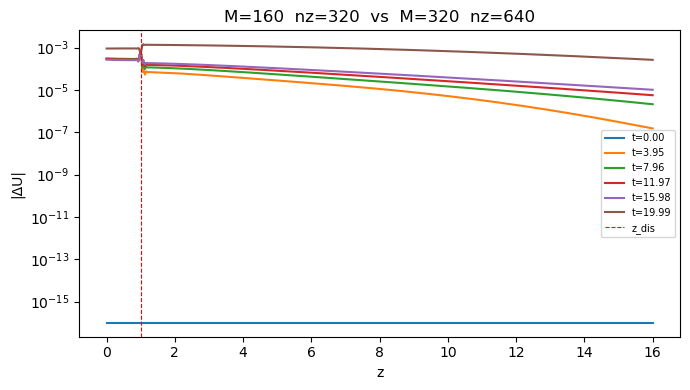

In [10]:
ref_key = pairs[0]   # (320, 640)
ref     = solvers[ref_key]
z_ref   = ref['z']
t_ref   = ref['t']
U_ref   = ref['U']
z_r2d, t_r2d = torch.meshgrid(z_ref, t_ref, indexing='ij')

n_cmp = len(pairs) - 1
fig, axes = plt.subplots(1, n_cmp, figsize=(7 * n_cmp, 4), sharey=True)
if n_cmp == 1: axes = [axes]

for ax, (M, nz) in zip(axes, pairs[1:]):
    sol  = solvers[(M, nz)]
    U_q  = sol['interp_pw'](z_r2d, t_r2d)
    err  = (U_q - U_ref).abs().cpu()
    idx  = torch.linspace(0, len(t_ref) - 1, 6).long()
    for i in idx:
        ax.semilogy(z_ref.cpu(), err[:, i].clamp(min=1e-16),
                    label=f't={t_ref[i].item():.2f}')
    ax.axvline(z_dis, color='r', linestyle='--', lw=0.8, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
    ax.set_title(f'M={M}  nz={nz}  vs  M={ref_key[0]}  nz={ref_key[1]}')
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()